In [1]:
# DAY 22 - FEATURE ENCODING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the cleaned Sales dataset

df = pd.read_csv("../cleaned_dataset.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
          order_id  order_date   ship_date       ship_mode    customer_name  \
0     AG-2011-2040  2011-01-01  2011-01-06  Standard Class  Toby Braunhardt   
1    IN-2011-47883  2011-01-01  2011-01-08  Standard Class      Joseph Holt   
2     HU-2011-1220  2011-01-01  2011-01-05    Second Class    Annie Thurman   
3  IT-2011-3647632  2011-01-01  2011-01-05    Second Class     Eugene Moren   
4    IN-2011-47883  2011-01-01  2011-01-08  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

                  product_name  sales quantity discount   profit  \
0          Tenex Lo

In [3]:
# Identify categorical columns

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'order_priority']


C:\Users\arjun\AppData\Local\Temp\ipykernel_20560\3691928889.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [4]:
# Check unique values in categorical columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique()[:10])


 order_id
<StringArray>
[   'AG-2011-2040',   'IN-2011-47883',    'HU-2011-1220', 'IT-2011-3647632',
    'CA-2011-1510',   'IN-2011-79397',   'ID-2011-80230',    'IZ-2011-4680',
   'IN-2011-65159', 'ES-2011-4869686']
Length: 10, dtype: str

 order_date
<StringArray>
['2011-01-01', '2011-01-02', '2011-01-03', '2011-01-04', '2011-01-05',
 '2011-01-06', '2011-01-07', '2011-01-08', '2011-01-09', '2011-01-10']
Length: 10, dtype: str

 ship_date
<StringArray>
['2011-01-06', '2011-01-08', '2011-01-05', '2011-01-03', '2011-01-09',
 '2011-01-07', '2011-01-11', '2011-01-10', '2011-01-13', '2011-01-12']
Length: 10, dtype: str

 ship_mode
<StringArray>
['Standard Class', 'Second Class', 'Same Day', 'First Class']
Length: 4, dtype: str

 customer_name
<StringArray>
[  'Toby Braunhardt',       'Joseph Holt',     'Annie Thurman',
      'Eugene Moren',   'Magdelene Morse',       'Kean Nguyen',
      'Ken Lonsdale',  'Lindsay Williams',      'Larry Blacks',
 'Dorothy Dickinson']
Length: 10, dtype: str

In [6]:
print("Column names in our dataset:")
print(df.columns.tolist())

Column names in our dataset:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin']


In [7]:
# Apply Label Encoding to Category

label_encoder = LabelEncoder()

df["category_label"] = label_encoder.fit_transform(df["category"])

print("Label Encoding completed!")
print(df[["category", "category_label"]].head(10))

Label Encoding completed!
          category  category_label
0  Office Supplies               1
1  Office Supplies               1
2  Office Supplies               1
3  Office Supplies               1
4        Furniture               0
5  Office Supplies               1
6       Technology               2
7  Office Supplies               1
8       Technology               2
9        Furniture               0


In [8]:
# Apply One-Hot Encoding to Segment

one_hot_df = pd.get_dummies(
    df,
    columns=["segment"],
    prefix="segment"
)

print("One-Hot Encoding completed!")
print(one_hot_df.head())
print("\nNew dataset shape:", one_hot_df.shape)

One-Hot Encoding completed!
          order_id  order_date   ship_date       ship_mode    customer_name  \
0     AG-2011-2040  2011-01-01  2011-01-06  Standard Class  Toby Braunhardt   
1    IN-2011-47883  2011-01-01  2011-01-08  Standard Class      Joseph Holt   
2     HU-2011-1220  2011-01-01  2011-01-05    Second Class    Annie Thurman   
3  IT-2011-3647632  2011-01-01  2011-01-05    Second Class     Eugene Moren   
4    IN-2011-47883  2011-01-01  2011-01-08  Standard Class      Joseph Holt   

             state    country  market   region        product_id  ...  \
0      Constantine    Algeria  Africa   Africa  OFF-TEN-10000025  ...   
1  New South Wales  Australia    APAC  Oceania   OFF-SU-10000618  ...   
2         Budapest    Hungary    EMEA     EMEA  OFF-TEN-10001585  ...   
3        Stockholm     Sweden      EU    North   OFF-PA-10001492  ...   
4  New South Wales  Australia    APAC  Oceania   FUR-FU-10003447  ...   

    profit shipping_cost order_priority  year  shipping_da

In [9]:
# Compare dataset before and after encoding

print("Original dataset shape:", df.shape)
print("Encoded dataset shape:", one_hot_df.shape)

print("\nOriginal columns:")
print(df.columns.tolist())

print("\nEncoded columns:")
print(one_hot_df.columns.tolist())

Original dataset shape: (51290, 24)
Encoded dataset shape: (51290, 26)

Original columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin', 'category_label']

Encoded columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin', 'category_label', 'segment_Consumer', 'segment_Corporate', 'segment_Home Office']


In [10]:
# Prepare features and target for baseline model

segment_columns = [
    col for col in one_hot_df.columns
    if col.startswith("segment_")
]

feature_columns = [
    "sales",
    "quantity",
    "discount",
    "shipping_cost",
    "shipping_days",
    "category_label"
] + segment_columns

X = one_hot_df[feature_columns].astype(float)

# Target: 1 = Profit is positive, 0 = Profit is zero/negative
y = (one_hot_df["profit"] > 0).astype(int)

print("Features prepared successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)


Features prepared successfully!
X shape: (51290, 9)
y shape: (51290,)


In [11]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data split successfully!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Data split successfully!
Training data: (41032, 9)
Testing data: (10258, 9)


In [12]:
# Train baseline Logistic Regression model

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

print("Baseline Logistic Regression trained successfully!")

Baseline Logistic Regression trained successfully!


In [13]:
# Make predictions and calculate accuracy

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline Accuracy:", round(baseline_accuracy, 3))

Baseline Accuracy: 0.92


In [14]:
# Prepare features before encoding

X_before = df[
    [
        "sales",
        "quantity",
        "discount",
        "shipping_cost",
        "shipping_days"
    ]
].astype(float)

y_before = (df["profit"] > 0).astype(int)

print("Before-encoding features prepared!")
print("X_before shape:", X_before.shape)
print("y_before shape:", y_before.shape)

Before-encoding features prepared!
X_before shape: (51290, 5)
y_before shape: (51290,)


In [15]:
# Train model before encoding

X_before_train, X_before_test, y_before_train, y_before_test = train_test_split(
    X_before,
    y_before,
    test_size=0.2,
    random_state=42,
    stratify=y_before
)

before_model = LogisticRegression(max_iter=1000)

before_model.fit(
    X_before_train,
    y_before_train
)

print("Before-encoding model trained successfully!")

Before-encoding model trained successfully!


In [16]:
# Calculate accuracy before encoding

before_pred = before_model.predict(X_before_test)

before_accuracy = accuracy_score(
    y_before_test,
    before_pred
)

print("Accuracy Before Encoding:", round(before_accuracy, 3))


Accuracy Before Encoding: 0.92


In [17]:
# Compare model performance before and after encoding

comparison_df = pd.DataFrame({
    "Model": ["Before Encoding", "After Encoding"],
    "Accuracy": [before_accuracy, baseline_accuracy]
})

print(comparison_df)

             Model  Accuracy
0  Before Encoding  0.920062
1   After Encoding  0.920257


In [18]:
# Save performance comparison

comparison_df.to_csv(
    "encoding_performance_comparison.csv",
    index=False
)

print("Performance comparison saved successfully!")
print(comparison_df)

Performance comparison saved successfully!
             Model  Accuracy
0  Before Encoding  0.920062
1   After Encoding  0.920257


In [19]:
# Save the encoded dataset

one_hot_df.to_csv(
    "encoded_dataset.csv",
    index=False
)

print("Encoded dataset saved successfully!")
print("File: encoded_dataset.csv")

Encoded dataset saved successfully!
File: encoded_dataset.csv


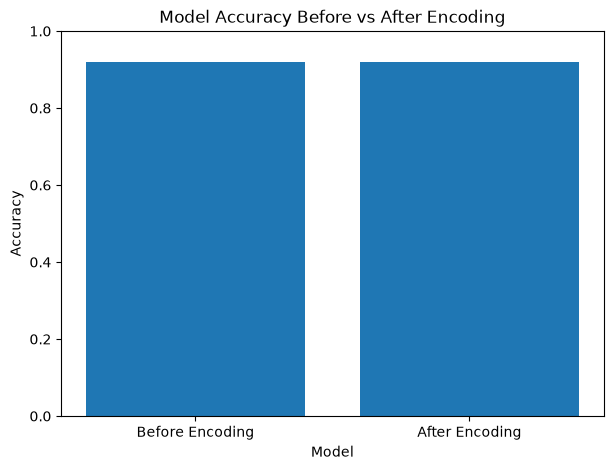

In [20]:
# Visualize accuracy before and after encoding

plt.figure(figsize=(7, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Before vs After Encoding")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

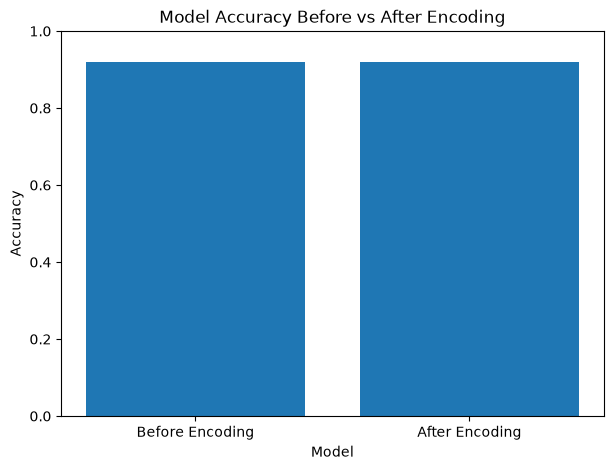

Graph saved successfully!


In [21]:
# Save the accuracy comparison graph

plt.figure(figsize=(7, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Before vs After Encoding")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.savefig(
    "encoding_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved successfully!")

In [22]:
# Final Day 22 file check

import os

files = [
    "encoded_dataset.csv",
    "encoding_performance_comparison.csv",
    "encoding_performance_comparison.png"
]

print("Day 22 files:")

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

Day 22 files:
✅ encoded_dataset.csv
✅ encoding_performance_comparison.csv
✅ encoding_performance_comparison.png
